# Advanced Method Development - Task 1: Explainability with Grad-CAM
This notebook implements and runs **Grad-CAM** (Gradient-weighted Class Activation Mapping) on the trained ConvNeXt V2 model to visualize and analyze the regions of an image that drive its predictions. 

We investigate:
1. **Randomized Correct Predictions**: Checking if the model focuses on the organism itself or background features.
2. **Randomized Incorrect Predictions (Failures)**: Analyzing what background noise or features distracted the model.
3. **Three Confusable Species Pairs**: Comparing activation maps for species of the same genus across 3 distinct taxonomic groups (Spiders, Bumblebees, Moths) using randomized image selection (`IMG_SEED = 100`).

**Note**: All output figures are automatically saved as seamless composite strips to `../report/image/grad_cam/` for LaTeX report inclusion.

In [273]:
import os
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from transformers import AutoImageProcessor, AutoModelForImageClassification

# Set global seed for sampling correct/incorrect test predictions
SEED = 92
np.random.seed(SEED)
torch.manual_seed(SEED)

# Output directory for LaTeX report images
output_dir = "../report/image/grad_cam"
os.makedirs(output_dir, exist_ok=True)
print(f"Output image directory set to: {output_dir}")

# Check device
device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device} | Random Seed: {SEED}")

Output image directory set to: ../report/image/grad_cam
Using device: mps | Random Seed: 92


In [274]:
# Load Model and Processor
model_path = "./model"
print("Loading model from:", model_path)
processor = AutoImageProcessor.from_pretrained(model_path)
model = AutoModelForImageClassification.from_pretrained(model_path).to(device)
model.eval()
print("Model loaded successfully!")

Loading model from: ./model


Loading weights: 100%|██████████| 200/200 [00:00<00:00, 7244.80it/s]


Model loaded successfully!


## 1. Custom Grad-CAM Implementation
We write a custom class to register forward and backward hooks on the last depthwise convolutional layer in `ConvNeXt V2`:
`model.convnextv2.encoder.stages[3].layers[2].dwconv`

In [275]:
class ConvNeXtGradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        
        # Register hooks
        self.forward_hook = self.target_layer.register_forward_hook(self.save_activation)
        self.backward_hook = self.target_layer.register_full_backward_hook(self.save_gradient)
        
    def save_activation(self, module, input, output):
        self.activations = output
        
    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]
        
    def generate_heatmap(self, inputs, class_idx=None):
        # Run forward pass
        outputs = self.model(**inputs)
        logits = outputs.logits
        
        if class_idx is None:
            class_idx = logits.argmax(-1).item()
            
        # Zero gradients
        self.model.zero_grad()
        
        # Compute gradients of target class score
        score = logits[0, class_idx]
        score.backward()
        
        # Get gradients and activations
        gradients = self.gradients[0]
        activations = self.activations[0]
        
        # Global Average Pooling of gradients
        weights = torch.mean(gradients, dim=(1, 2))
        
        # Weighted sum of activations
        cam = torch.zeros(activations.shape[1:], dtype=torch.float32, device=activations.device)
        for i, w in enumerate(weights):
            cam += w * activations[i]
            
        # ReLU & Normalization
        cam = torch.relu(cam)
        cam_min, cam_max = cam.min(), cam.max()
        if cam_max > cam_min:
            cam = (cam - cam_min) / (cam_max - cam_min)
        else:
            cam = torch.zeros_like(cam)
            
        probs = torch.softmax(logits[0], dim=-1)
        return cam.detach().cpu().numpy(), class_idx, logits[0].detach().cpu().numpy(), probs[class_idx].item()
        
    def remove_hooks(self):
        if hasattr(self, 'forward_hook') and self.forward_hook:
            self.forward_hook.remove()
        if hasattr(self, 'backward_hook') and self.backward_hook:
            self.backward_hook.remove()

## 2. Helper Functions for Visualization and Image Export
We generate seamless composite strips containing [Original | Heatmap | Overlay] side-by-side without internal padding.

In [276]:
def get_label_name(model, class_idx):
    id2label = model.config.id2label
    if id2label and str(class_idx) in id2label:
        return id2label[str(class_idx)]
    elif id2label and class_idx in id2label:
        return id2label[class_idx]
    return f"Class_{class_idx}"

def show_gradcam_overlay(image_path, heatmap, pred_idx, true_label, save_filename=None):
    img = Image.open(image_path).convert("RGB")
    heatmap_img = Image.fromarray(np.uint8(255 * heatmap)).resize(img.size, resample=Image.Resampling.BILINEAR)
    colormap = plt.get_cmap("jet")
    heatmap_colored = colormap(np.array(heatmap_img) / 255.0)[:, :, :3]
    heatmap_colored = np.uint8(255 * heatmap_colored)
    heatmap_colored_img = Image.fromarray(heatmap_colored)
    overlay = Image.blend(img, heatmap_colored_img, alpha=0.4)
    
    fig, axes = plt.subplots(1, 3, figsize=(10, 3.3), gridspec_kw={'wspace': 0.01})
    axes[0].imshow(img)
    axes[0].axis("off")
    
    axes[1].imshow(heatmap_img, cmap="jet")
    axes[1].axis("off")
    
    axes[2].imshow(overlay)
    axes[2].axis("off")
    
    plt.subplots_adjust(left=0, right=1, bottom=0, top=1, wspace=0.01, hspace=0)
    
    if save_filename:
        save_path = os.path.join(output_dir, save_filename)
        plt.savefig(save_path, dpi=300, bbox_inches='tight', pad_inches=0.02)
        print(f"Saved composite strip to: {save_path}")
        
    plt.show()

## 3. Run Grad-CAM Analysis
We instantiate Grad-CAM on the target layer: `model.convnextv2.encoder.stages[3].layers[2].dwconv`

In [277]:
target_layer = model.convnextv2.encoder.stages[3].layers[2].dwconv
cam_extractor = ConvNeXtGradCAM(model, target_layer)

### Case 1: Randomized Correct and Incorrect Predictions 
We gather test images, sample **2 correct** and **2 incorrect** predictions, and export composite strips.

=== CORRECT PREDICTIONS (SEED=92) ===
Correct 1: True='Pachodynerus erynnis', Pred='Pachodynerus erynnis', Top-1 Prob=0.8703
Saved composite strip to: ../report/image/grad_cam/gradcam_correct_1.png


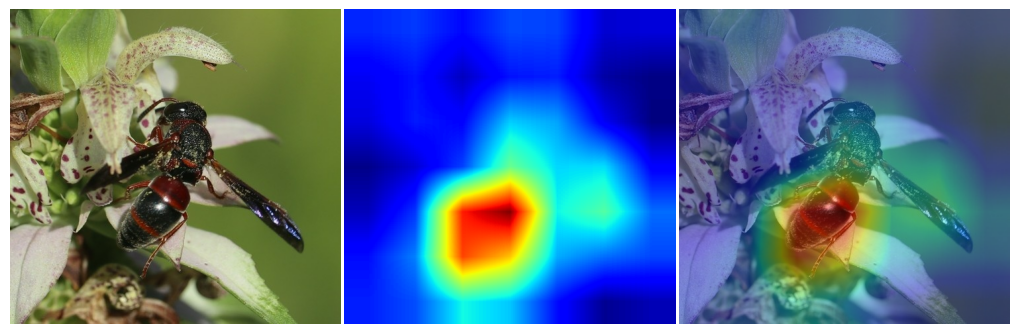

Correct 2: True='Scaevola taccada', Pred='Scaevola taccada', Top-1 Prob=0.1133
Saved composite strip to: ../report/image/grad_cam/gradcam_correct_2.png


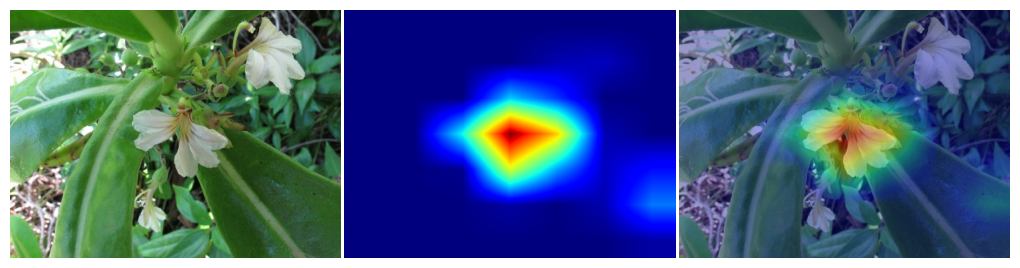


=== INCORRECT PREDICTIONS (SEED=92) ===
Incorrect 1: True='Wahlenbergia marginata', Pred='Wahlenbergia albomarginata', Top-1 Prob=0.0356
Saved composite strip to: ../report/image/grad_cam/gradcam_incorrect_1.png


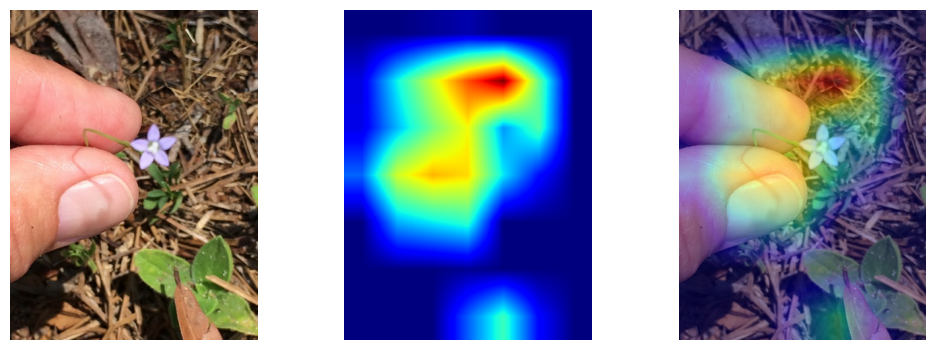

Incorrect 2: True='Caloscypha fulgens', Pred='Peltigera membranacea', Top-1 Prob=0.0310
Saved composite strip to: ../report/image/grad_cam/gradcam_incorrect_2.png


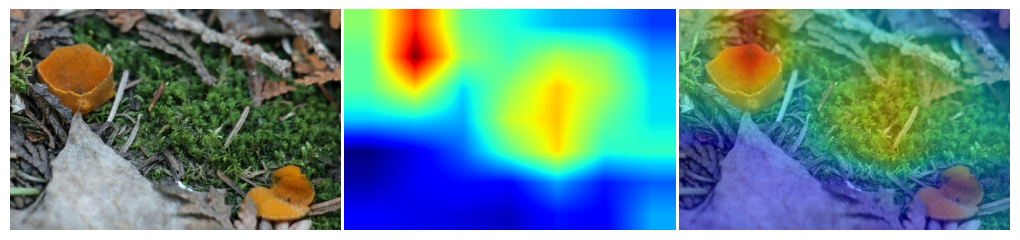

In [278]:
test_dir = "./data/test_select"

all_image_paths = []
for root, dirs, files in os.walk(test_dir):
    for file in files:
        if file.lower().endswith(('.png', '.jpg', '.jpeg')):
            all_image_paths.append((os.path.join(root, file), os.path.basename(root)))

np.random.seed(SEED)
shuffled_indices = np.random.permutation(len(all_image_paths))

correct_samples = []
incorrect_samples = []

for idx in shuffled_indices:
    image_path, true_label = all_image_paths[idx]
    img = Image.open(image_path).convert("RGB")
    inputs = processor(images=img, return_tensors="pt").to(device)
    heatmap, pred_idx, _, prob = cam_extractor.generate_heatmap(inputs)
    pred_label = get_label_name(model, pred_idx)
    
    sample_info = {
        "path": image_path,
        "true_label": true_label,
        "pred_label": pred_label,
        "pred_idx": pred_idx,
        "heatmap": heatmap,
        "prob": prob
    }
    
    if true_label == pred_label:
        if len(correct_samples) < 2:
            correct_samples.append(sample_info)
    else:
        if len(incorrect_samples) < 2:
            incorrect_samples.append(sample_info)
            
    if len(correct_samples) >= 2 and len(incorrect_samples) >= 2:
        break

print("=== CORRECT PREDICTIONS (SEED=92) ===")
for i, sample in enumerate(correct_samples):
    true_name = ' '.join(sample['true_label'].split('_')[-2:])
    pred_name = ' '.join(sample['pred_label'].split('_')[-2:])
    print(f"Correct {i+1}: True='{true_name}', Pred='{pred_name}', Top-1 Prob={sample['prob']:.4f}")
    save_name = f"gradcam_correct_{i+1}.png"
    show_gradcam_overlay(sample["path"], sample["heatmap"], sample["pred_idx"], sample["true_label"], save_filename=save_name)

print("\n=== INCORRECT PREDICTIONS (SEED=92) ===")
for i, sample in enumerate(incorrect_samples):
    true_name = ' '.join(sample['true_label'].split('_')[-2:])
    pred_name = ' '.join(sample['pred_label'].split('_')[-2:])
    print(f"Incorrect {i+1}: True='{true_name}', Pred='{pred_name}', Top-1 Prob={sample['prob']:.4f}")
    save_name = f"gradcam_incorrect_{i+1}.png"
    show_gradcam_overlay(sample["path"], sample["heatmap"], sample["pred_idx"], sample["true_label"], save_filename=save_name)

### Case 2: Three Confusable Species Pairs (Fine-Grained Analysis)
We select **3 confusable pairs** (Spiders, Bumblebees, Moths). To avoid hardcoding image filenames, we randomly sample image files inside each folder using a distinct image generator seed. Output details and predictions are printed.

Saved as:
- `gradcam_confusable_steatoda_1.png` & `gradcam_confusable_steatoda_2.png`
- `gradcam_confusable_bombus_1.png` & `gradcam_confusable_bombus_2.png`
- `gradcam_confusable_pyrausta_1.png` & `gradcam_confusable_pyrausta_2.png`

=== CONFUSABLE SPECIES PAIRS (IMG_SEED=100) ===

Group: Steatoda (Spiders)
  [STEATODA 1] True: 'Steatoda capensis' | Pred: 'Steatoda capensis' (Prob: 0.3292) | Status: CORRECT | File: d9012fff-3ac8-45f2-98c7-cb1c9a550977.jpg
Saved composite strip to: ../report/image/grad_cam/gradcam_confusable_steatoda_1.png


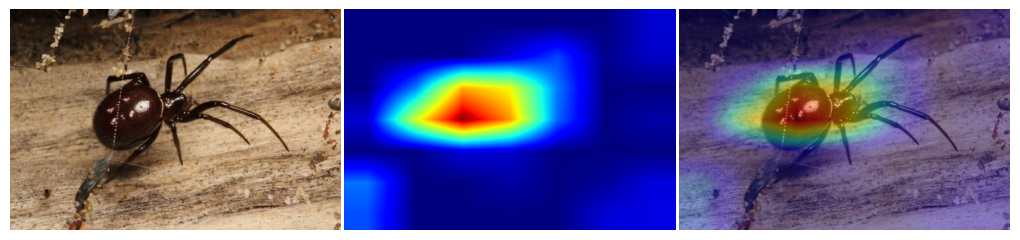

  [STEATODA 2] True: 'Steatoda grossa' | Pred: 'Steatoda grossa' (Prob: 0.3977) | Status: CORRECT | File: f9248a9b-bc84-45cc-90f6-9bac2dabd725.jpg
Saved composite strip to: ../report/image/grad_cam/gradcam_confusable_steatoda_2.png


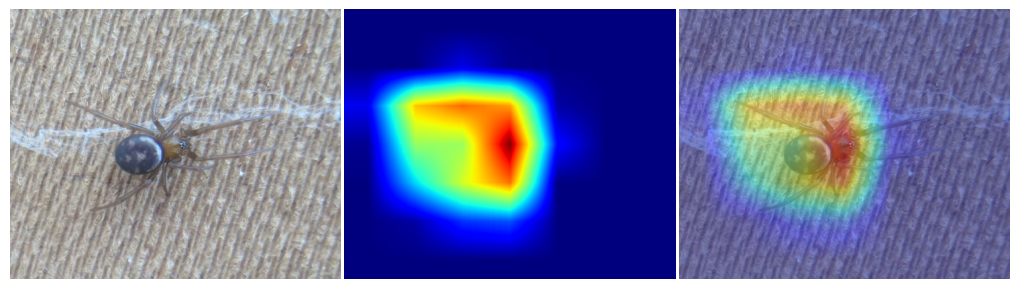


Group: Bombus (Bumblebees)
  [BOMBUS 1] True: 'Bombus huntii' | Pred: 'Bombus huntii' (Prob: 0.2010) | Status: CORRECT | File: 90e903d5-0398-4aa3-870a-14d8c0b5c7f6.jpg
Saved composite strip to: ../report/image/grad_cam/gradcam_confusable_bombus_1.png


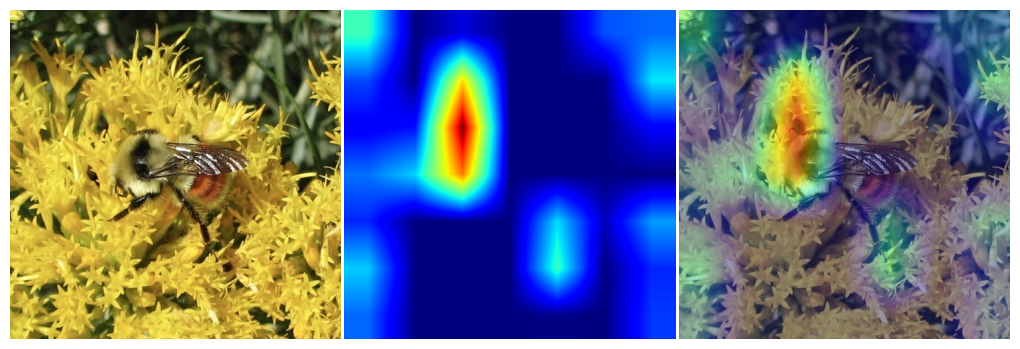

  [BOMBUS 2] True: 'Bombus mixtus' | Pred: 'Bombus mixtus' (Prob: 0.8920) | Status: CORRECT | File: cd0c0227-ec3d-44d5-ba8b-182b4c3de6ec.jpg
Saved composite strip to: ../report/image/grad_cam/gradcam_confusable_bombus_2.png


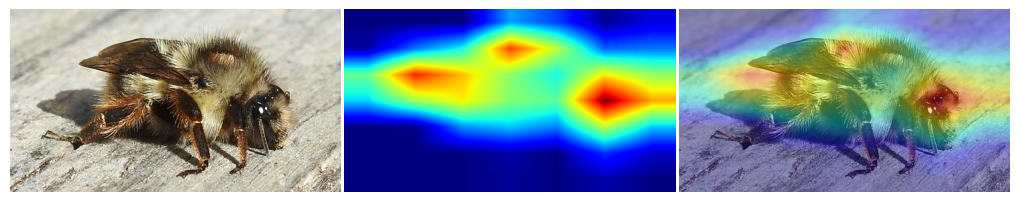


Group: Pyrausta (Moths)
  [PYRAUSTA 1] True: 'Pyrausta purpuralis' | Pred: 'Pyrausta purpuralis' (Prob: 0.3538) | Status: CORRECT | File: 74311a4d-e2e1-48eb-a5ff-82a69a459175.jpg
Saved composite strip to: ../report/image/grad_cam/gradcam_confusable_pyrausta_1.png


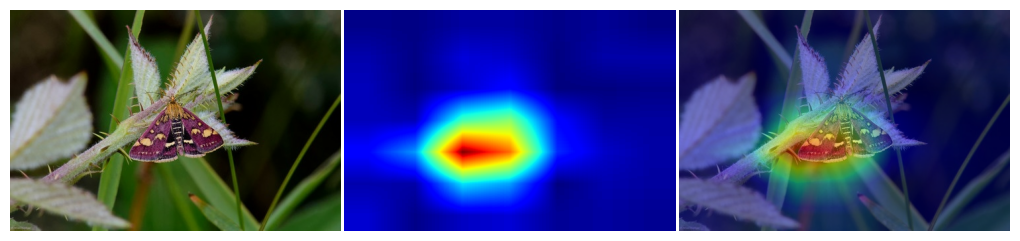

  [PYRAUSTA 2] True: 'Pyrausta aurata' | Pred: 'Pyrausta aurata' (Prob: 0.4671) | Status: CORRECT | File: 055be9c1-ecc0-4cd8-b43f-d40c38f1ab55.jpg
Saved composite strip to: ../report/image/grad_cam/gradcam_confusable_pyrausta_2.png


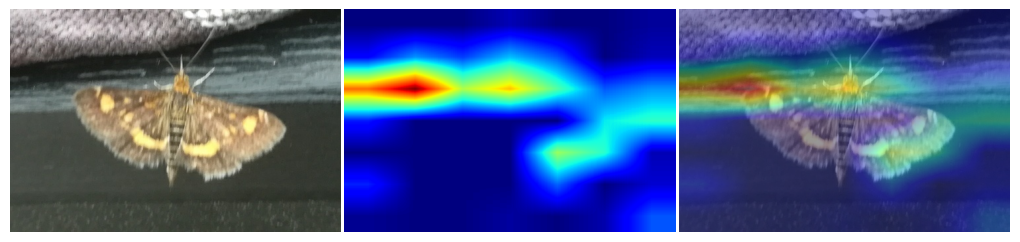

In [279]:
confusable_pairs = [
    ("steatoda", "Steatoda (Spiders)", [
        "00121_Animalia_Arthropoda_Arachnida_Araneae_Theridiidae_Steatoda_capensis",
        "00122_Animalia_Arthropoda_Arachnida_Araneae_Theridiidae_Steatoda_grossa"
    ]),
    ("bombus", "Bombus (Bumblebees)", [
        "00688_Animalia_Arthropoda_Insecta_Hymenoptera_Apidae_Bombus_huntii",
        "00693_Animalia_Arthropoda_Insecta_Hymenoptera_Apidae_Bombus_mixtus"
    ]),
    ("pyrausta", "Pyrausta (Moths)", [
        "00934_Animalia_Arthropoda_Insecta_Lepidoptera_Crambidae_Pyrausta_purpuralis",
        "00928_Animalia_Arthropoda_Insecta_Lepidoptera_Crambidae_Pyrausta_aurata"
    ])
]

# Random seed specifically for image selection inside species folders (IMG_SEED = 100)
img_rng = np.random.RandomState(100)

print("=== CONFUSABLE SPECIES PAIRS (IMG_SEED=100) ===")
for tag, group_name, folders in confusable_pairs:
    print(f"\nGroup: {group_name}")
    for i, folder in enumerate(folders):
        folder_path = os.path.join(test_dir, folder)
        files = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))])
        chosen_file = img_rng.choice(files)
        img_path = os.path.join(folder_path, chosen_file)
        
        img = Image.open(img_path).convert("RGB")
        inputs = processor(images=img, return_tensors="pt").to(device)
        heatmap, pred_idx, _, prob = cam_extractor.generate_heatmap(inputs)
        pred_label = get_label_name(model, pred_idx)
        
        true_name = ' '.join(folder.split('_')[-2:])
        pred_name = ' '.join(pred_label.split('_')[-2:])
        match_status = "CORRECT" if folder == pred_label else "MISCLASSIFIED"
        
        print(f"  [{tag.upper()} {i+1}] True: '{true_name}' | Pred: '{pred_name}' (Prob: {prob:.4f}) | Status: {match_status} | File: {chosen_file}")
        
        save_name = f"gradcam_confusable_{tag}_{i+1}.png"
        show_gradcam_overlay(img_path, heatmap, pred_idx, folder, save_filename=save_name)

In [280]:
# Clean up hooks
cam_extractor.remove_hooks()
print("Grad-CAM hooks successfully removed.")

Grad-CAM hooks successfully removed.
